**Loading dataset and understanding data**

In [1]:
import numpy as np
import pandas as pd

In [2]:
TRAIN_FILE_PATH = "train.csv"
TEST_FILE_PATH = "test.csv"

In [3]:
df = pd.read_csv(TRAIN_FILE_PATH)
test_df = pd.read_csv(TEST_FILE_PATH)

In [4]:
df.shape, test_df.shape

((7613, 5), (3263, 4))

**Preprocessing data**

In [5]:
for col in df.columns:
    print(f"COLUMN NAME: {col}\t\t\t\t MISSING VALUES: {df[col].isnull().sum()}")

COLUMN NAME: id				 MISSING VALUES: 0
COLUMN NAME: keyword				 MISSING VALUES: 61
COLUMN NAME: location				 MISSING VALUES: 2533
COLUMN NAME: text				 MISSING VALUES: 0
COLUMN NAME: target				 MISSING VALUES: 0


Since, lot's of value are missing in the *location* column, it's better we drop this column, also there is no significant value that *location* column provides in determining whether it's diaster or not.
<br/>
**Strategy to fill missing values in keyword column**
<br/>
As we can see it's a categorical column it's better if we fill this value with `mode()` strategy.
<br/>
For training purpose, we are dropping the **id** column as well and merging the content of **keyword** and **text** column into one single column named as **complete_text**.

In [6]:
new_df = df.drop(columns=[ 'id', 'location' ])

In [7]:
new_df.shape

(7613, 3)

In [8]:
MISSING_KEYWORD_FILLER_VALUE = df['keyword'].mode().values[0]
MISSING_KEYWORD_FILLER_VALUE

'fatalities'

In [9]:
print(new_df['keyword'].isnull().sum())
new_df.fillna( {'keyword': MISSING_KEYWORD_FILLER_VALUE}, inplace=True)
print(new_df['keyword'].isnull().sum())

61
0


In [10]:
new_df['complete_text'] = new_df['keyword'] + " " + new_df['text']
new_df.drop(columns=['keyword', 'text'], inplace=True)
new_df.shape

(7613, 2)

In [11]:
new_df.sample(1)

,target,complete_text
2849,0,displaced @cityofhummus @ILNewsFlash do you wa...


**Cleaning data**
<br/>
As we can see there are lot's of *special symbols* and `@user_names` which we've to remove.
<br/>
+ Things we've to keep includes numbers, since it's a disaster mgmt. dataset no. tells important information. that's why keep them.
+ Also, keeping all the hastags, might be a possibility that the hastags provides the disaster names or actual distaster which occured.

In [12]:
import re
import torch

In [13]:
def clean_data(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)             # remove mentions
    text = re.sub(r'#', '', text)                # keep hashtag words
    text = re.sub(r'\s+', ' ', text).strip()     # clean whitespace
    return text

In [14]:
clean_data(new_df.sample(1)['complete_text'].values[0])

'terrorist udhampuragain 2 terrorist shot dead.. udhampur'

In [15]:
new_df['complete_text'] = new_df['complete_text'].apply(lambda x: clean_data(x))

In [16]:
new_df.sample(1)

,target,complete_text
561,0,battle do your own thing: the battle of intern...


**Before going any further**, first split the dataset for training and testing.

In [17]:
texts = new_df['complete_text'].values
labels = new_df['target'].values

In [18]:
type(texts), type(labels)

(numpy.ndarray, numpy.ndarray)

In [22]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, random_state=23, stratify=labels)
train_texts.shape, val_texts.shape, train_labels.shape, val_labels.shape

((6090,), (1523,), (6090,), (1523,))

For Handling the data imbalance here, we're use the weight assignment strategy.

0    3473
1    2617
Name: count, dtype: int64


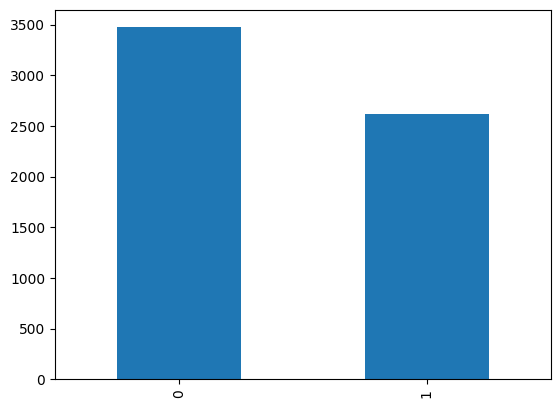

In [26]:
pd.Series(train_labels).value_counts().plot(kind='bar')
print(
    pd.Series(train_labels).value_counts()
)

In [27]:
from sklearn.utils import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = dict(zip(np.unique(train_labels), class_weights))
print(class_weights)

{np.int64(0): np.float64(0.8767636049524906), np.int64(1): np.float64(1.1635460450897974)}


**Preprocessing over**, Let's begin with the model training part, for text classification we've decided to use the `roberta-base` model, which provides better performance than the `distilbert-base-uncased`.

In [28]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from torch.utils.data import Dataset

In [29]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [30]:
MODEL_NAME = 'roberta-base'

In [31]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [36]:
MAX_LENGTH = max(
    [ len(sentence) for sentence in train_texts ]
)
MAX_LENGTH

164

As we can see there are at max. 164 length text, so no need of 512 max token limit, therefore we're using 256 as `max_padding` value.

In [39]:
train_encoding = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [41]:
class TextDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings=encodings
    self.labels=labels

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    item={key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels'] = torch.tensor(self.labels[idx])
    return item

In [42]:
train_dataset = TextDataset(train_encoding, train_labels)
val_dataset = TextDataset(val_encodings, val_labels)

In [44]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)
model = model.to(device=DEVICE)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [46]:
from sklearn.metrics import accuracy_score, f1_score
from transformers import Trainer, TrainingArguments

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions)
    }

In [52]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    lr_scheduler_type='cosine',
    learning_rate=1e-5,
    warmup_ratio=0.1,
    warmup_steps=100,
    metric_for_best_model='f1',
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [53]:
from transformers import DataCollatorWithPadding
from transformers import EarlyStoppingCallback

data_collactor = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collactor,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [54]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.235383,0.558272,0.790545,0.764576
2,0.403202,0.395141,0.842416,0.800995
3,0.314533,0.485559,0.827315,0.805617
4,0.265829,0.500386,0.840446,0.814078
5,0.232540,0.575973,0.831911,0.806354
6,0.202740,0.694295,0.833880,0.804633
7,0.120713,0.859031,0.826658,0.804734


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2667, training_loss=0.2593375618287048, metrics={'train_runtime': 700.3893, 'train_samples_per_second': 86.952, 'train_steps_per_second': 5.44, 'total_flos': 1336331800175400.0, 'train_loss': 0.2593375618287048, 'epoch': 7.0})

In [55]:
trainer.evaluate()

{'eval_loss': 0.5011807084083557,
 'eval_accuracy': 0.8391332895600788,
 'eval_f1': 0.8128342245989305,
 'eval_runtime': 2.9024,
 'eval_samples_per_second': 524.737,
 'eval_steps_per_second': 65.807,
 'epoch': 7.0}

In [56]:
test_df = test_df.drop(columns=[ 'location' ])
test_df.fillna( {'keyword': MISSING_KEYWORD_FILLER_VALUE}, inplace=True)

In [57]:
test_df['complete_text'] = test_df['keyword'] + " " + test_df['text']

In [58]:
test_df['complete_text'] = test_df['complete_text'].apply(lambda x: clean_data(x))

In [59]:
all_testing_samples = test_df['complete_text'].values

In [70]:
inputs = tokenizer(
    list(all_testing_samples),
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors='pt'
)

inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

In [71]:
with torch.no_grad():
  outputs = model(**inputs)

predictions = torch.argmax(outputs.logits, dim=1)

In [72]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'target': predictions.cpu().numpy()
})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print(submission.shape)

   id  target
0   0       1
1   2       1
2   3       1
3   9       1
4  11       1
(3263, 2)
